In [ ]:
!wget -O exp_2_linus_torvalds.jpeg "https://drive.google.com/file/d/1QkHHRyqPC2IQLVKFg151b-R3sSpNUuK_/view?usp=sharing"

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Read the image
image = cv2.imread("exp_2_linus_torvalds.jpeg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

In [8]:
# Less Bright Filter
def less_bright(img, factor=0.5):
    return np.clip(img * factor, 0, 255).astype(np.uint8)

# More Bright Filter
def more_bright(img, factor=1.5):
    return np.clip(img * factor, 0, 255).astype(np.uint8)

In [9]:
# Image Sharpening Filter
def sharpen(img):
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    return cv2.filter2D(img, -1, kernel)

In [10]:
# Sepia Filter
def sepia(img):
    kernel = np.array([[0.272, 0.534, 0.131],
                       [0.349, 0.686, 0.168],
                       [0.393, 0.769, 0.189]])
    sepia_img = cv2.transform(img, kernel)
    return np.clip(sepia_img, 0, 255).astype(np.uint8)

In [11]:
# Grey Pencil Sketch
def grey_pencil_sketch(img):
    grey_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    inv_img = cv2.bitwise_not(grey_img)
    blur_img = cv2.GaussianBlur(inv_img, (21, 21), 0)
    sketch = cv2.divide(grey_img, 255 - blur_img, scale=256)
    return sketch

# Color Pencil Sketch
def color_pencil_sketch(img):
    grey, sketch = cv2.pencilSketch(img, sigma_s=60, sigma_r=0.07, shade_factor=0.05)
    return sketch

In [12]:
# HDR Filter
def hdr(img):
    return cv2.detailEnhance(img, sigma_s=12, sigma_r=0.15)

# Invert Filter
def invert(img):
    return cv2.bitwise_not(img)

# Grey Scale Filter
def grey_scale(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

In [13]:
# Apply filters
filters = {
    'Original': image,
    'Grey Scale': grey_scale(image),
    'Less Bright': less_bright(image),
    'More Bright': more_bright(image),
    'Sharpened': sharpen(image),
    'Sepia': sepia(image),
    'Grey Pencil Sketch': grey_pencil_sketch(image),
    'Color Pencil Sketch': color_pencil_sketch(image),
    'HDR': hdr(image),
    'Invert': invert(image)
}

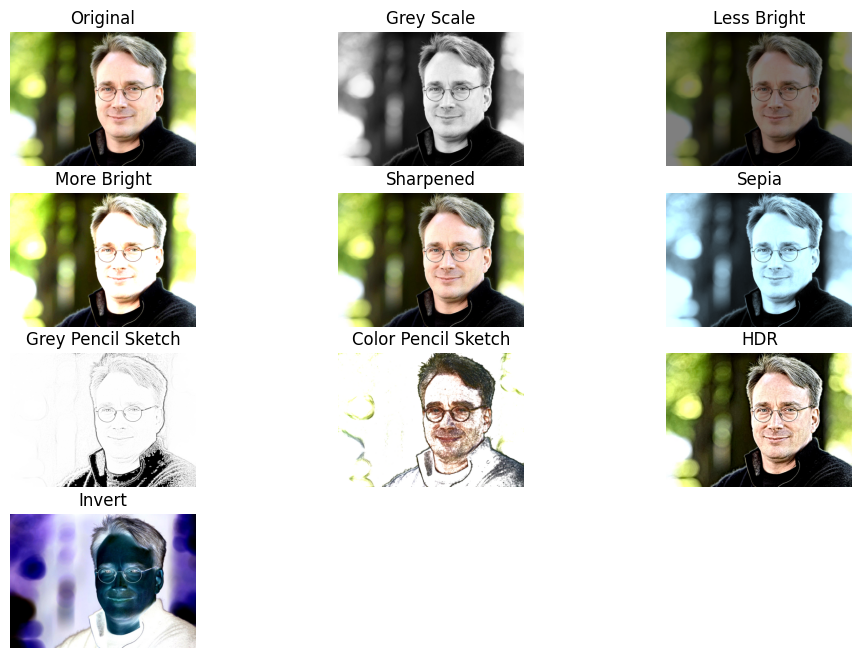

In [14]:
# Display the results
plt.figure(figsize=(12, 8))
for i, (name, img_filter) in enumerate(filters.items()):
    plt.subplot(4, 3, i+1)
    if len(img_filter.shape) == 2:
        plt.imshow(img_filter, cmap='gray')
    else:
        plt.imshow(img_filter)
    plt.title(name)
    plt.axis('off')
plt.show()